# Statistics & Analysis — MITRE ATT&CK Pipeline

## Purpose of This Notebook

This notebook is the **final stage** of the cybersecurity event pipeline.

It loads classification results produced by `Consumer_Classifier.ipynb` and provides:

- basic event statistics,
- MITRE ATT&CK tactic and technique frequency analysis,
- per-user and per-host breakdowns,
- visual plots for presentation and reporting.

This stage runs **after** the pipeline — it does not interact with Kafka or Jaeger.

---

## Key Idea

> Analysis happens *after* the pipeline, not inside it.

In real SOC systems, this corresponds to a SIEM dashboard, a threat intelligence
report, or a periodic batch analytics job.


## 0. Install Dependencies

In [1]:
!pip install -q pandas matplotlib seaborn


## 1. Load Classified Events

Load `classified_packets.csv` produced by the Consumer & Classifier stage.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# The CSV is written by Consumer_Classifier.ipynb in the same directory.
CSV_PATH = "classified_packets.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])
print(f"Loaded {len(df)} classified events.")
print()
print("Columns:", df.columns.tolist())
print()
df.head(10)


Loaded 120 classified events.

Columns: ['event_id', 'timestamp', 'user', 'host', 'source_ip', 'event_type', 'mitre_tactic', 'mitre_technique']



,event_id,timestamp,user,host,source_ip,event_type,mitre_tactic,mitre_technique
0,8b54a574-6021-4e0c-a051-0f34081e969d,2026-06-27 08:11:59.377138+00:00,charlie,win-01,10.0.0.10,user_login,TA0006,T1110
1,17b41c92-3ef1-458f-9411-93b7e0825774,2026-06-27 08:12:02.377138+00:00,alice,win-03,10.0.0.11,process_start,TA0002,T1059.001
2,5356e0b5-50f7-4f5b-9036-4214fb2777ee,2026-06-27 08:12:05.377138+00:00,bob,win-01,10.0.0.12,process_start,TA0002,T1059.001
3,931a5543-c49c-498b-b5af-dfaa36ad8f85,2026-06-27 08:12:20.377138+00:00,bob,win-03,10.0.0.12,user_login,TA0006,T1110
4,6a55a0e3-b3be-4507-b591-ba949a742e0e,2026-06-27 08:12:23.377138+00:00,bob,win-02,10.0.0.12,user_login,TA0006,T1110
5,8edaa143-864e-442a-8d24-875d66046d22,2026-06-27 08:12:14.377138+00:00,bob,win-03,10.0.0.11,process_start,TA0002,T1059.003
6,52d51304-c8fb-4b53-96a6-c127e00393ae,2026-06-27 08:12:23.377138+00:00,bob,win-02,10.0.0.10,process_start,TA0002,T1059.003
7,84b8f693-a4e8-47b1-be85-ad5b9031ff76,2026-06-27 08:12:20.377138+00:00,charlie,win-02,10.0.0.12,process_start,TA0002,T1059.001
8,ab161d70-77cd-4279-afd2-bc1ac858ff52,2026-06-27 08:12:23.377138+00:00,admin,win-03,10.0.0.10,process_start,TA0002,T1059.003
9,93ca6ebe-ff56-4d38-9197-457bca1d1924,2026-06-27 08:12:53.377138+00:00,alice,win-03,10.0.0.11,user_login,TA0001,T1078


## 2. Basic Statistics

In [3]:
print("=== Dataset Overview ===")
print(f"Total events   : {len(df)}")
print(f"Unique users   : {df['user'].nunique()}")
print(f"Unique hosts   : {df['host'].nunique()}")
print(f"Unique tactics : {df['mitre_tactic'].nunique()}")
print(f"Unique techniques : {df['mitre_technique'].nunique()}")
print()
print("=== Event Type Distribution ===")
print(df["event_type"].value_counts().to_string())
print()
print("=== Date Range ===")
print(f"First event : {df['timestamp'].min()}")
print(f"Last event  : {df['timestamp'].max()}")


=== Dataset Overview ===
Total events   : 120
Unique users   : 4
Unique hosts   : 3
Unique tactics : 3
Unique techniques : 5

=== Event Type Distribution ===
event_type
user_login       65
process_start    55

=== Date Range ===
First event : 2026-06-27 08:11:59.377138+00:00
Last event  : 2026-06-27 08:27:03.377138+00:00


## 3. MITRE ATT&CK Tactic Frequency

Each tactic code maps to a MITRE ATT&CK tactic name:

| Code   | Tactic Name           |
|--------|-----------------------|
| TA0001 | Initial Access        |
| TA0002 | Execution             |
| TA0006 | Credential Access     |
| TA0000 | Unknown / Other       |


=== MITRE Tactic Counts ===
tactic_name
Execution            55
Credential Access    33
Initial Access       32



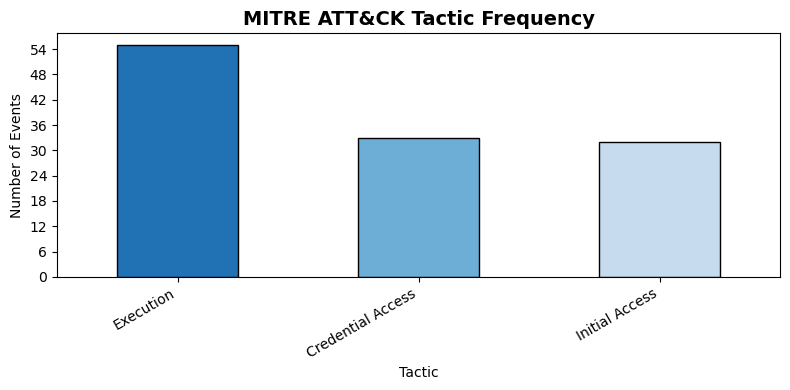

Chart saved as tactic_frequency.png


In [4]:
TACTIC_NAMES = {
    "TA0001": "Initial Access",
    "TA0002": "Execution",
    "TA0006": "Credential Access",
    "TA0000": "Unknown",
}

df["tactic_name"] = df["mitre_tactic"].map(TACTIC_NAMES).fillna(df["mitre_tactic"])

tactic_counts = df["tactic_name"].value_counts()
print("=== MITRE Tactic Counts ===")
print(tactic_counts.to_string())
print()

fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette("Blues_r", len(tactic_counts))
tactic_counts.plot(kind="bar", ax=ax, color=colors, edgecolor="black")
ax.set_title("MITRE ATT&CK Tactic Frequency", fontsize=14, fontweight="bold")
ax.set_xlabel("Tactic")
ax.set_ylabel("Number of Events")
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("tactic_frequency.png", dpi=120)
plt.show()
print("Chart saved as tactic_frequency.png")


## 4. MITRE ATT&CK Technique Frequency

Each technique maps to a specific adversary behavior:

| Code      | Technique Name                       |
|-----------|--------------------------------------|
| T1059.001 | Command and Scripting: PowerShell    |
| T1059.003 | Command and Scripting: Windows Shell |
| T1059     | Command and Scripting (generic)      |
| T1110     | Brute Force                          |
| T1078     | Valid Accounts                       |


=== MITRE Technique Counts ===
technique_name
Brute Force       33
Valid Accounts    32
PowerShell        24
Windows Shell     18
Cmd Scripting     13



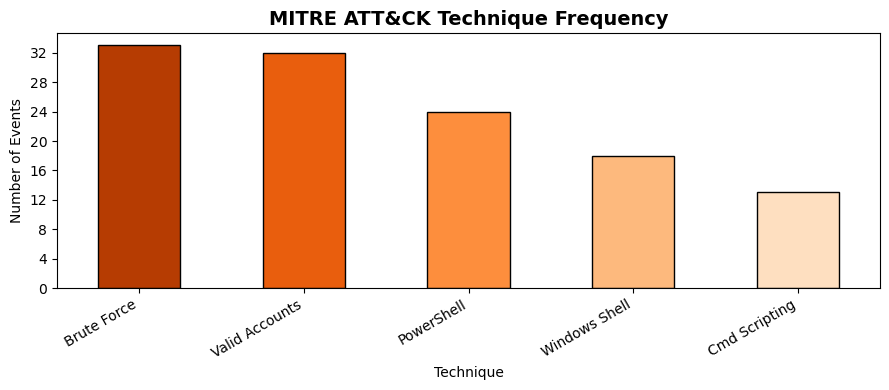

Chart saved as technique_frequency.png


In [5]:
TECHNIQUE_NAMES = {
    "T1059.001": "PowerShell",
    "T1059.003": "Windows Shell",
    "T1059":     "Cmd Scripting",
    "T1110":     "Brute Force",
    "T1078":     "Valid Accounts",
    "T0000":     "Unknown",
}

df["technique_name"] = df["mitre_technique"].map(TECHNIQUE_NAMES).fillna(df["mitre_technique"])

technique_counts = df["technique_name"].value_counts()
print("=== MITRE Technique Counts ===")
print(technique_counts.to_string())
print()

fig, ax = plt.subplots(figsize=(9, 4))
colors = sns.color_palette("Oranges_r", len(technique_counts))
technique_counts.plot(kind="bar", ax=ax, color=colors, edgecolor="black")
ax.set_title("MITRE ATT&CK Technique Frequency", fontsize=14, fontweight="bold")
ax.set_xlabel("Technique")
ax.set_ylabel("Number of Events")
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("technique_frequency.png", dpi=120)
plt.show()
print("Chart saved as technique_frequency.png")


## 5. Events per User

=== Events per User ===
user
admin      34
bob        33
charlie    32
alice      21



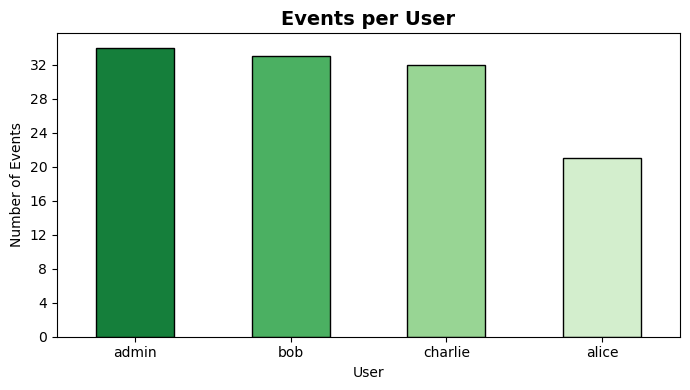

In [6]:
user_counts = df["user"].value_counts()
print("=== Events per User ===")
print(user_counts.to_string())
print()

fig, ax = plt.subplots(figsize=(7, 4))
colors = sns.color_palette("Greens_r", len(user_counts))
user_counts.plot(kind="bar", ax=ax, color=colors, edgecolor="black")
ax.set_title("Events per User", fontsize=14, fontweight="bold")
ax.set_xlabel("User")
ax.set_ylabel("Number of Events")
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("events_per_user.png", dpi=120)
plt.show()


## 6. Events per Host

=== Events per Host ===
host
win-01    42
win-03    42
win-02    36



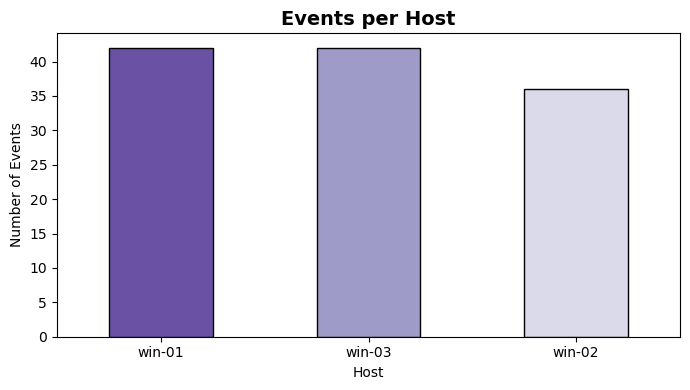

In [7]:
host_counts = df["host"].value_counts()
print("=== Events per Host ===")
print(host_counts.to_string())
print()

fig, ax = plt.subplots(figsize=(7, 4))
colors = sns.color_palette("Purples_r", len(host_counts))
host_counts.plot(kind="bar", ax=ax, color=colors, edgecolor="black")
ax.set_title("Events per Host", fontsize=14, fontweight="bold")
ax.set_xlabel("Host")
ax.set_ylabel("Number of Events")
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("events_per_host.png", dpi=120)
plt.show()


## 7. Tactic vs Event Type Heatmap

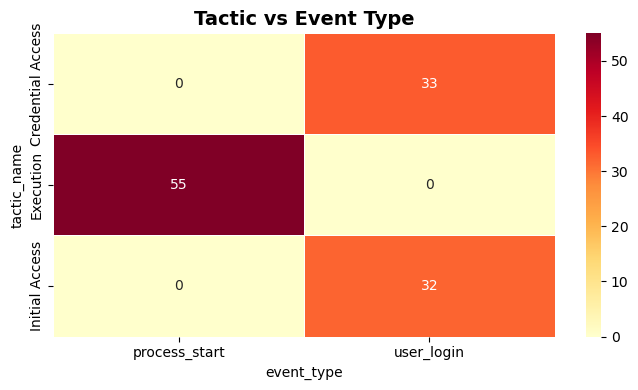

In [8]:
pivot = df.groupby(["tactic_name", "event_type"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Tactic vs Event Type", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("tactic_event_heatmap.png", dpi=120)
plt.show()


## 8. Event Timeline (events per minute)

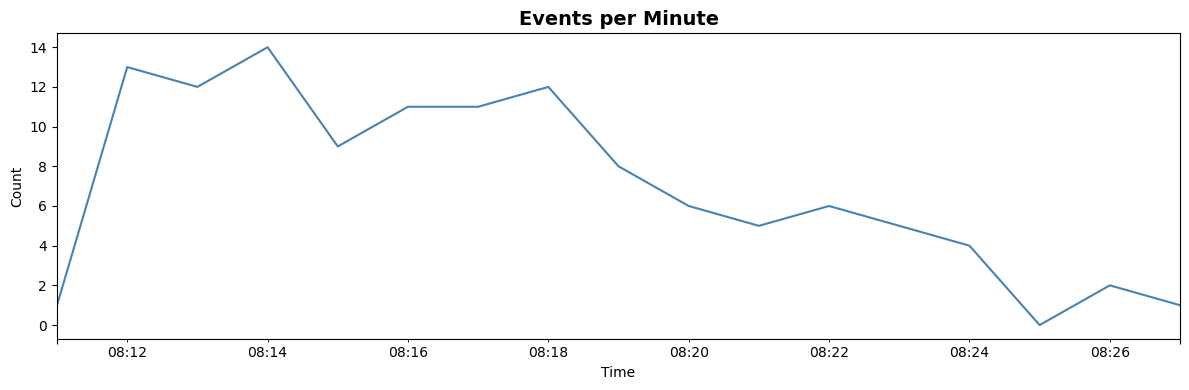

In [9]:
df_sorted = df.set_index("timestamp").sort_index()
events_per_minute = df_sorted.resample("1min").size()

fig, ax = plt.subplots(figsize=(12, 4))
events_per_minute.plot(ax=ax, color="steelblue", linewidth=1.5)
ax.set_title("Events per Minute", fontsize=14, fontweight="bold")
ax.set_xlabel("Time")
ax.set_ylabel("Count")
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig("event_timeline.png", dpi=120)
plt.show()


## 9. Conceptual Questions

### Q1: Why is Kafka used instead of direct function calls?

Kafka decouples producers from consumers. The producer does not need to know
who will process the data, does not wait for a response, and can continue
producing at full speed even if the consumer is temporarily unavailable.
This ensures buffering under load, fault tolerance, and the ability to scale
producers and consumers independently — all critical properties in a real SOC
pipeline that ingests millions of events per day.

---

### Q2: What happens if the consumer is slower than the producer?

Kafka acts as a buffer. Events accumulate in the topic and are not lost.
The consumer will eventually catch up. The lag (difference between produced
and consumed offsets) can be monitored using Kafka consumer group lag metrics
or in Redpanda Console. In a real system, the solution is to run multiple
consumer instances in the same consumer group — Kafka automatically partitions
the work between them.

---

### Q3: How does tracing help debug pipeline behavior?

Jaeger shows the full lifecycle of a single event across all pipeline stages.
Without tracing, you can only observe each stage in isolation. With tracing,
you can see:
- which stage introduced latency,
- whether an event was dropped between stages,
- the exact order of operations for a specific event.
This is critical when debugging production issues in distributed systems.

---

### Q4: Which pipeline stages could be scaled independently?

- **Producers** can be scaled by adding more data sources.
- **Consumers** can be scaled by adding instances to the same consumer group
  (Kafka distributes partitions between them).
- **Analysis** (this notebook) runs independently of the pipeline and can be
  scheduled as a batch job.
- **Kafka itself** can be scaled with more partitions and brokers.
The producer and consumer are fully independent — this is the core benefit of
using a message queue.

---

### Q5: How would this pipeline change in a real SOC system?

In a real SOC:
- Events would come from EDR agents, firewalls, and OS log forwarders, not
  from synthetic generators.
- Classification would use trained ML models or SIEM rules, not simple
  keyword matching.
- Storage would be a time-series database (Elasticsearch, ClickHouse) instead
  of CSV files.
- Analysis dashboards (Kibana, Grafana) would replace Jupyter notebooks.
- The pipeline would handle millions of events per second, not dozens.
- Alerting and incident response workflows would be triggered automatically.

The **architecture** (producer → queue → consumer → storage → analysis) remains
the same at any scale. That is the key takeaway of this lab.


## 10. Summary

This notebook demonstrated the final analytics stage of the cybersecurity
event pipeline:

| Step | What was done |
|------|---------------|
| Load | Read `classified_packets.csv` produced by the Consumer stage |
| Stats | Counted events, users, hosts, tactics, techniques |
| Tactic chart | Visualized MITRE tactic frequency |
| Technique chart | Visualized MITRE technique frequency |
| Per-user | Identified which users generated the most events |
| Per-host | Identified which hosts were most active |
| Heatmap | Cross-tabulated tactic vs event type |
| Timeline | Visualized event rate over time |

> Key takeaway: **In cybersecurity, pipelines matter more than models.**
> This lab showed how data flows from generation through classification
> to structured analysis — the foundation of every real SIEM system.
